<a href="https://colab.research.google.com/github/kushb2011/JPMorgan-Chase-Fraud-Detection/blob/main/Final_Project_Kush_Bhuva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necesarry Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Turn data inot data frame

df = pd.read_csv('fraud_payment_data')

In [ ]:
# Look at data

print(df.info)

<bound method DataFrame.info of                    Time_step         Transaction_Id            Sender_Id  \
0        2022-03-15 10:24:00         EXCHANGE-10115    JPMC-CLIENT-10098   
1        2022-03-15 10:24:00    QUICK-PAYMENT-10116    JPMC-CLIENT-10098   
2        2022-03-15 10:24:00      DEPOSIT-CASH-9833                  NaN   
3        2022-03-15 10:24:00         PAY-CHECK-9832     JPMC-CLIENT-9812   
4        2022-03-15 10:24:00     DEPOSIT-CHECK-9806                  NaN   
...                      ...                    ...                  ...   
1498172  2054-09-14 13:17:24       PAY-BILL-2180018  JPMC-CLIENT-2179746   
1498173  2054-09-15 00:57:24  QUICK-PAYMENT-2181421  JPMC-CLIENT-2181147   
1498174  2054-09-15 01:17:24        PAYMENT-2180021  JPMC-CLIENT-2179746   
1498175  2054-09-15 12:57:24  QUICK-PAYMENT-2181422  JPMC-CLIENT-2181147   
1498176  2054-09-15 13:07:24  QUICK-PAYMENT-2181423  JPMC-CLIENT-2181147   

          Sender_Account Sender_Country  Sender_Sector 

In [ ]:
# Check Missing Data

display(df.isnull().sum()/len(df))

,0
Time_step,0.000000
Transaction_Id,0.000000
Sender_Id,0.146102
Sender_Account,0.146102
Sender_Country,0.146102
Sender_Sector,0.146102
Sender_lob,0.146102
Bene_Id,0.144104
Bene_Account,0.144104
Bene_Country,0.144104


In [ ]:
# Replace all NaN values with 'Missing' before splitting
import pandas as pd

for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(object)
        df[col] = df[col].fillna('Missing')

print("Replaced all NaN values with 'Missing' in the original dataframe.")
display(df.isnull().sum())

Replaced all NaN values with 'Missing' in the original dataframe.


,0
Time_step,0
Transaction_Id,0
Sender_Id,0
Sender_Account,0
Sender_Country,0
Sender_Sector,0
Sender_lob,0
Bene_Id,0
Bene_Account,0
Bene_Country,0


In [ ]:
#Look at first 5 rows

df.head()

,Time_step,Transaction_Id,Sender_Id,Sender_Account,Sender_Country,Sender_Sector,Sender_lob,Bene_Id,Bene_Account,Bene_Country,USD_amount,Label,Transaction_Type
0,2022-03-15 10:24:00,EXCHANGE-10115,JPMC-CLIENT-10098,ACCOUNT-10108,USA,35537.0,CCB,Missing,Missing,Missing,558.43,0,WITHDRAWAL
1,2022-03-15 10:24:00,QUICK-PAYMENT-10116,JPMC-CLIENT-10098,ACCOUNT-10109,USA,15287.0,CCB,CLIENT-10100,ACCOUNT-10106,CANADA,622.78,0,QUICK-PAYMENT
2,2022-03-15 10:24:00,DEPOSIT-CASH-9833,Missing,Missing,Missing,Missing,Missing,JPMC-CLIENT-9812,ACCOUNT-9826,USA,802.54,0,DEPOSIT-CASH
3,2022-03-15 10:24:00,PAY-CHECK-9832,JPMC-CLIENT-9812,ACCOUNT-9825,USA,38145.0,CCB,JPMC-CLIENT-9814,ACCOUNT-9824,USA,989.09,0,PAY-CHECK
4,2022-03-15 10:24:00,DEPOSIT-CHECK-9806,Missing,Missing,Missing,Missing,Missing,JPMC-CLIENT-9789,ACCOUNT-9800,USA,786.78,0,DEPOSIT-CHECK


In [ ]:
# Look at the distribution and basic stats of Sender_lob
#Only one unique value so this can be dropped

print("Number of unique Line of Businesses (LOB):", df['Sender_lob'].nunique())
print("\nMost common LOBs:")
display(df['Sender_lob'].value_counts())
print("\nBasic statistics:")
display(df['Sender_lob'].describe())

Number of unique Line of Businesses (LOB): 2

Most common LOBs:


,count
Sender_lob,
CCB,1279291
Missing,218886



Basic statistics:


,Sender_lob
count,1498177
unique,2
top,CCB
freq,1279291


In [ ]:
# Look at the distribution and basic stats of Transaction_Type
print("Number of unique Transaction Types:", df['Transaction_Type'].nunique())
print("\nMost common Transaction Types:")
display(df['Transaction_Type'].value_counts())
print("\nBasic statistics:")
display(df['Transaction_Type'].describe())

Number of unique Transaction Types: 8

Most common Transaction Types:


,count
Transaction_Type,
MAKE-PAYMENT,557735
QUICK-PAYMENT,217607
MOVE-FUNDS,180205
DEPOSIT-CHECK,109477
DEPOSIT-CASH,109409
EXCHANGE,108167
PAY-CHECK,107851
WITHDRAWAL,107726



Basic statistics:


,Transaction_Type
count,1498177
unique,8
top,MAKE-PAYMENT
freq,557735


In [ ]:
# Look at the distribution and basic stats of Sender_Sector
# Will need to change or drop colmn, too many options for categorical variable
print("Number of unique sectors:", df['Sender_Sector'].nunique())
print("\nTop 10 most common sectors:")
display(df['Sender_Sector'].value_counts().head(10))
print("\nBasic statistics:")
display(df['Sender_Sector'].describe())

Number of unique sectors: 50001

Top 10 most common sectors:


,count
Sender_Sector,
Missing,218886
46269.0,50
47521.0,49
25097.0,47
1311.0,46
37878.0,46
33770.0,46
34643.0,45
39362.0,45



Basic statistics:


,Sender_Sector
count,1498177
unique,50001
top,Missing
freq,218886


In [ ]:
# Look at distribution of fraud vs no fraud
# Very imbalanced

display(df['Label'].value_counts())

,count
Label,
0,1467358
1,30819


In [ ]:
# Look at list of countries
# The USA shows up twice

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df['Sender_Country'].value_counts())

,count
Sender_Country,
USA,997236
Missing,218886
GERMANY,73431
CANADA,27383
LIECHTENSTEIN,1163
THAILAND,1157
FRENCH-GUIANA,1148
KUWAIT,1134
MAURITANIA,1116


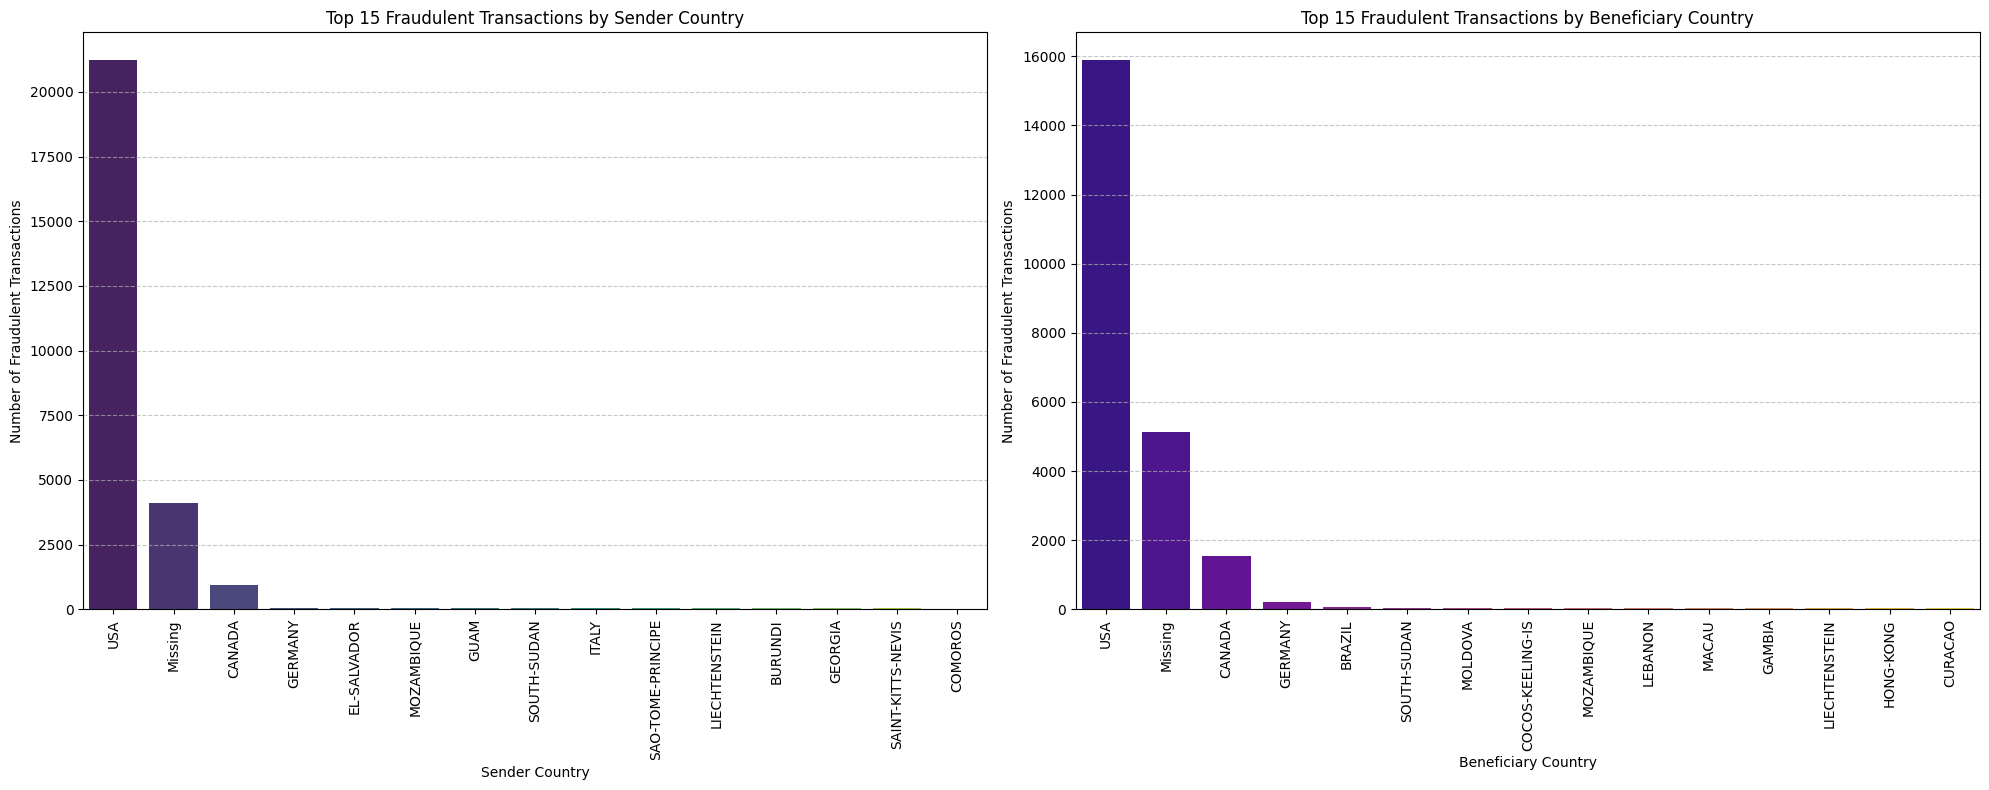

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the original DataFrame for fraudulent transactions
fraud_df_original = df[df['Label'] == 1]

# Count fraudulent transactions by Sender_Country
fraud_by_sender_country = fraud_df_original['Sender_Country'].value_counts().reset_index()
fraud_by_sender_country.columns = ['Country', 'Fraud_Count']

# Count fraudulent transactions by Bene_Country
fraud_by_bene_country = fraud_df_original['Bene_Country'].value_counts().reset_index()
fraud_by_bene_country.columns = ['Country', 'Fraud_Count']

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot for Sender_Country (top 15 for readability)
sns.barplot(x='Country', y='Fraud_Count', data=fraud_by_sender_country.head(15), ax=axes[0], palette='viridis', hue='Country', legend=False)
axes[0].set_title('Top 15 Fraudulent Transactions by Sender Country')
axes[0].set_xlabel('Sender Country')
axes[0].set_ylabel('Number of Fraudulent Transactions')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Bene_Country (top 15 for readability)
sns.barplot(x='Country', y='Fraud_Count', data=fraud_by_bene_country.head(15), ax=axes[1], palette='plasma', hue='Country', legend=False)
axes[1].set_title('Top 15 Fraudulent Transactions by Beneficiary Country')
axes[1].set_xlabel('Beneficiary Country')
axes[1].set_ylabel('Number of Fraudulent Transactions')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

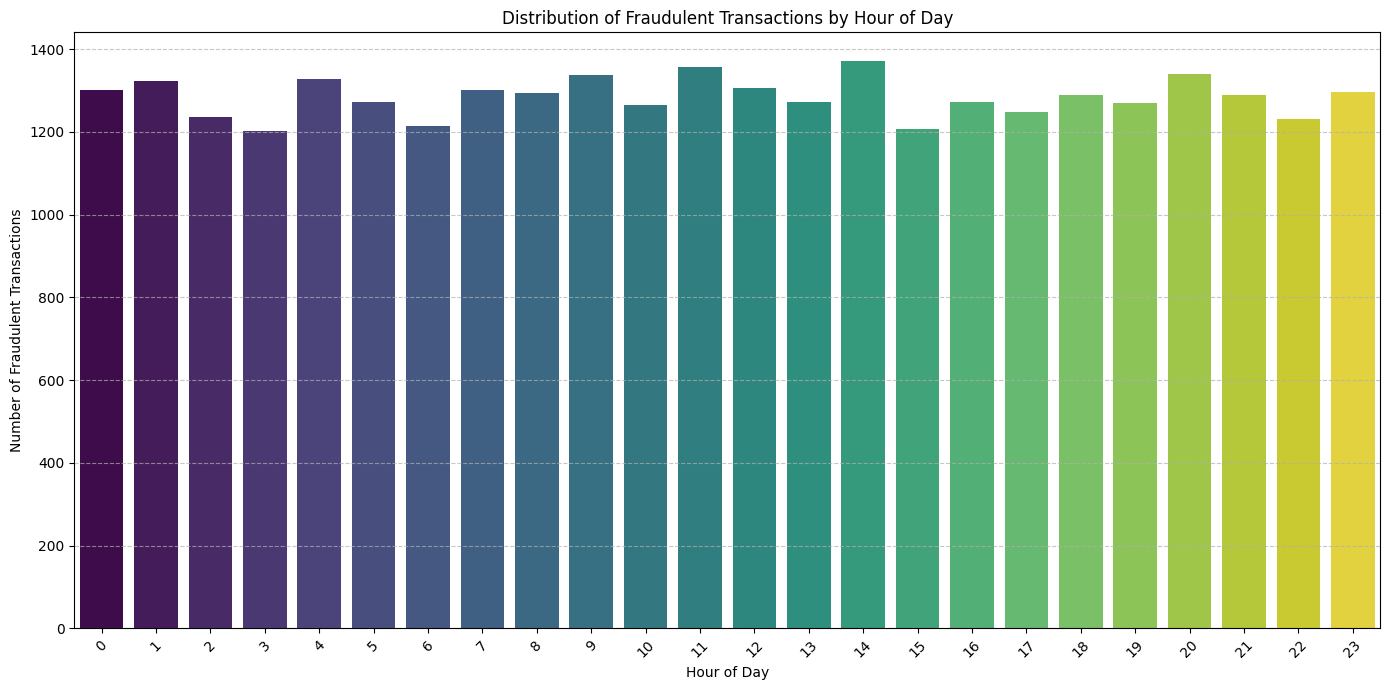

In [ ]:
df['Time_step'] = pd.to_datetime(df['Time_step'])
df['Hour_of_Day'] = df['Time_step'].dt.hour

plt.figure(figsize=(14, 7))
sns.countplot(data=df[df['Label'] == 1], x='Hour_of_Day', hue='Hour_of_Day', palette='viridis', legend=False)
plt.title('Distribution of Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

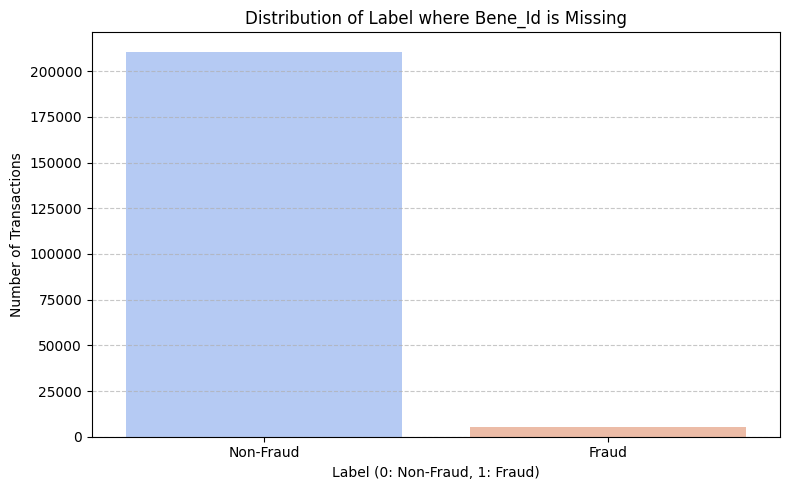

In [ ]:
# Distribution of Label where Bene_Id is 'Missing'
plt.figure(figsize=(8, 5))
sns.countplot(data=df[df['Bene_Id'] == 'Missing'], x='Label', hue='Label', palette='coolwarm', legend=False)
plt.title('Distribution of Label where Bene_Id is Missing')
plt.xlabel('Label (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

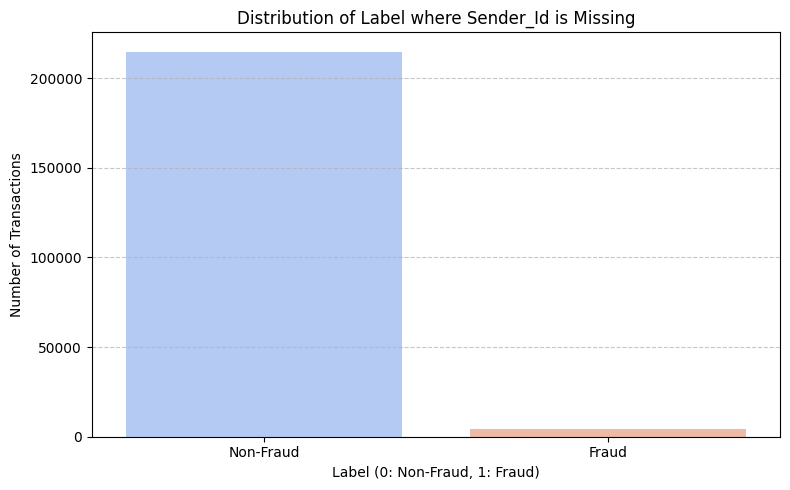

In [ ]:
# Distribution of Label where Sender_Id is 'Missing'
plt.figure(figsize=(8, 5))
sns.countplot(data=df[df['Sender_Id'] == 'Missing'], x='Label', hue='Label', palette='coolwarm', legend=False)
plt.title('Distribution of Label where Sender_Id is Missing')
plt.xlabel('Label (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Ensure the data is sorted chronologically
df = df.sort_values('Time_step')

# Create a cumulative count of transactions between each Sender and Beneficiary pair.
# A cumcount of 0 means it's the first time this Sender is sending to this Beneficiary.
df['Is_New_Beneficiary'] = (df.groupby(['Sender_Id', 'Bene_Id']).cumcount() == 0).astype(int)

print("Created 'Is_New_Beneficiary' flag.")
print("\nValue Counts:")
display(df['Is_New_Beneficiary'].value_counts())

# Preview the new feature
display(df[['Time_step', 'Sender_Id', 'Bene_Id', 'Is_New_Beneficiary']].head(10))

Created 'Is_New_Beneficiary' flag.

Value Counts:


,count
Is_New_Beneficiary,
0,1160102
1,338075


,Time_step,Sender_Id,Bene_Id,Is_New_Beneficiary
0,2022-03-15 10:24:00,JPMC-CLIENT-10098,Missing,1
68,2022-03-15 10:24:00,Missing,JPMC-CLIENT-3439,1
67,2022-03-15 10:24:00,JPMC-CLIENT-3719,CLIENT-3721,1
66,2022-03-15 10:24:00,JPMC-CLIENT-3719,Missing,1
65,2022-03-15 10:24:00,JPMC-CLIENT-3997,Missing,1
64,2022-03-15 10:24:00,JPMC-CLIENT-4020,JPMC-COMPANY-4025,1
63,2022-03-15 10:24:00,JPMC-CLIENT-4020,CLIENT-4038,1
62,2022-03-15 10:24:00,Missing,JPMC-CLIENT-4196,1
61,2022-03-15 10:24:00,JPMC-CLIENT-4196,COMPANY-4202,1
60,2022-03-15 10:24:00,JPMC-CLIENT-4475,CLIENT-4494,1


In [ ]:
# Ensure the data is sorted chronologically
df = df.sort_values('Time_step')

# Create a cumulative count of transactions between each Sender and Sector pair.
# A cumcount of 0 means it's the first time this Sender is interacting with this Sector.
df['Is_New_Sector'] = (df.groupby(['Sender_Id', 'Sender_Sector']).cumcount() == 0).astype(int)

print("Created 'Is_New_Sector' flag.")
print("\nValue Counts:")
display(df['Is_New_Sector'].value_counts())

# Preview the new feature
display(df[['Time_step', 'Sender_Id', 'Sender_Sector', 'Is_New_Sector']].head(10))


Created 'Is_New_Sector' flag.

Value Counts:


,count
Is_New_Sector,
1,1277839
0,220338


,Time_step,Sender_Id,Sender_Sector,Is_New_Sector
0,2022-03-15 10:24:00,JPMC-CLIENT-10098,35537.0,1
46,2022-03-15 10:24:00,COMPANY-5230,9801.0,1
1,2022-03-15 10:24:00,JPMC-CLIENT-10098,15287.0,1
2,2022-03-15 10:24:00,Missing,Missing,1
3,2022-03-15 10:24:00,JPMC-CLIENT-9812,38145.0,1
4,2022-03-15 10:24:00,Missing,Missing,0
5,2022-03-15 10:24:00,JPMC-CLIENT-9763,14645.0,1
6,2022-03-15 10:24:00,Missing,Missing,0
8,2022-03-15 10:24:00,CLIENT-9502,25040.0,1
9,2022-03-15 10:24:00,JPMC-CLIENT-9229,34576.0,1


In [ ]:
# 1. Day of the Week
# Make sure df['Time_step'] is already converted to datetime
df['Day_of_Week'] = df['Time_step'].dt.day_name()

# 2. Round Number Flag
df['Is_Round_Amount'] = (df['USD_amount'] % 1 == 0).astype(int)

print("Added 'Day_of_Week' and 'Is_Round_Amount' to the main df.")
display(df[['Time_step', 'Day_of_Week', 'USD_amount', 'Is_Round_Amount']].head())

Added 'Day_of_Week' and 'Is_Round_Amount' to the main df.


,Time_step,Day_of_Week,USD_amount,Is_Round_Amount
0,2022-03-15 10:24:00,Tuesday,558.43,0
46,2022-03-15 10:24:00,Tuesday,669.70,0
1,2022-03-15 10:24:00,Tuesday,622.78,0
2,2022-03-15 10:24:00,Tuesday,802.54,0
3,2022-03-15 10:24:00,Tuesday,989.09,0


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Label', axis=1)
y = df['Label']

# Step 1: Split into Train (70%) and Temp (30%)
# We use stratify=y to maintain the proportion of fraud/non-fraud cases
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Training set shape: {X_train.shape}, Target shape: {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, Target shape: {y_val.shape}")
print(f"Testing set shape: {X_test.shape}, Target shape: {y_test.shape}")

Training set shape: (1048723, 17), Target shape: (1048723,)
Validation set shape: (224727, 17), Target shape: (224727,)
Testing set shape: (224727, 17), Target shape: (224727,)


In [ ]:
# Replace 'UNITED-STATES' with 'USA' in the country columns
for dataset in [X_train, X_val, X_test]:
    dataset['Sender_Country'] = dataset['Sender_Country'].replace('UNITED-STATES', 'USA')
    dataset['Bene_Country'] = dataset['Bene_Country'].replace('UNITED-STATES', 'USA')
    # Re-calculate Same_Country to reflect the standardized names
    dataset['Same_Country'] = (dataset['Sender_Country'] == dataset['Bene_Country']).astype(int)

print("Replaced 'UNITED-STATES' with 'USA' and updated 'Same_Country' feature.")

Replaced 'UNITED-STATES' with 'USA' and updated 'Same_Country' feature.


In [ ]:
# Add binary feature for same country
for dataset in [X_train, X_val, X_test]:
    dataset['Same_Country'] = (dataset['Sender_Country'] == dataset['Bene_Country']).astype(int)

print("Added 'Same_Country' feature to train, validation, and test sets.")
# Display a quick preview from the training set
display(X_train[['Sender_Country', 'Bene_Country', 'Same_Country']].head())

Added 'Same_Country' feature to train, validation, and test sets.


,Sender_Country,Bene_Country,Same_Country
511707,NIGERIA,USA,0
1049769,USA,USA,1
1494953,USA,Missing,0
215886,HUNGARY,MARTINIQUE,0
743597,USA,USA,1


In [ ]:
for dataset in [X_train, X_val, X_test]:
    dataset['Sender_ID_Missing'] = (dataset['Sender_Id'] == 'Missing').astype(int)
    dataset['Bene_ID_Missing'] = (dataset['Bene_Id'] == 'Missing').astype(int)

print("Added 'Sender_ID_Missing' and 'Bene_ID_Missing' features to train, validation, and test sets.")
# Display a quick preview from the training set
display(X_train[['Sender_Id', 'Sender_ID_Missing', 'Bene_Id', 'Bene_ID_Missing']].head())

Added 'Sender_ID_Missing' and 'Bene_ID_Missing' features to train, validation, and test sets.


,Sender_Id,Sender_ID_Missing,Bene_Id,Bene_ID_Missing
511707,JPMC-CLIENT-742459,0,BILL-COMPANY-742637,0
1049769,JPMC-CLIENT-1534490,0,COMPANY-1534496,0
1494953,JPMC-CLIENT-2176486,0,Missing,1
215886,JPMC-CLIENT-309221,0,BILL-COMPANY-309420,0
743597,CLIENT-1086501,0,JPMC-CLIENT-1086500,0


In [ ]:
!pip install pycountry_convert

In [ ]:
import pycountry_convert as pc
import pandas as pd

def country_to_continent(country_name):
    if country_name == 'Missing' or pd.isna(country_name):
        return 'Missing'
    try:
        # Handle standardized names from previous steps
        if country_name == 'USA':
            country_name = 'United States'
        else:
            # Replace hyphens with spaces and convert to Title Case
            country_name = country_name.replace('-', ' ').title()

        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return 'Unknown'

# Apply mapping to train, val, and test sets
for dataset in [X_train, X_val, X_test]:
    dataset['Sender_Continent'] = dataset['Sender_Country'].apply(country_to_continent)
    dataset['Bene_Continent'] = dataset['Bene_Country'].apply(country_to_continent)

print("Mapped countries to continents successfully.")
# Display a quick preview from the training set
display(X_train[['Sender_Country', 'Sender_Continent', 'Bene_Country', 'Bene_Continent']].head())

# Quick check to ensure Unknowns are reduced
print("\nSender_Continent value counts:")
display(X_train['Sender_Continent'].value_counts())

Mapped countries to continents successfully.


,Sender_Country,Sender_Continent,Bene_Country,Bene_Continent
511707,NIGERIA,Africa,USA,North America
1049769,USA,North America,USA,North America
1494953,USA,North America,Missing,Missing
215886,HUNGARY,Europe,MARTINIQUE,North America
743597,USA,North America,USA,North America



Sender_Continent value counts:


,count
Sender_Continent,
North America,731878
Missing,153345
Europe,74095
Asia,26464
Africa,26067
Unknown,18118
Oceania,10538
South America,7560
Antarctica,658


In [ ]:
# Check which countries are still mapped to 'Unknown'
unknown_sender_countries = X_train[X_train['Sender_Continent'] == 'Unknown']['Sender_Country'].value_counts()
print("Countries mapped to 'Unknown' in Sender_Country:")
display(unknown_sender_countries)

unknown_bene_countries = X_train[X_train['Bene_Continent'] == 'Unknown']['Bene_Country'].value_counts()
print("\nCountries mapped to 'Unknown' in Bene_Country:")
display(unknown_bene_countries)

Countries mapped to 'Unknown' in Sender_Country:


,count
Sender_Country,
SAINT-HELENA-ASCENSION-AND-TRISTAN-DA-CUNHA,664
TURKS-AND-CAICOS-IS,639
SAO-TOME-PRINCIPE,637
SINT-EUSTATIUS-AND-SABA,634
WALLIS-FUTUNA-IS,617
MINOR-OUTLYING-ISLANDS,601
CONGO-REP,598
TIMOR-LESTE,595
N-MARIANA-IS,595



Countries mapped to 'Unknown' in Bene_Country:


,count
Bene_Country,
RUSSIAN,1310
N-MARIANA-IS,1266
HEARD-ISLAND-AND-MCDONALD-ISLANDS,1224
TURKS-AND-CAICOS-IS,1217
MINOR-OUTLYING-ISLANDS,1165
PITCAIRN,1161
CURACAO,1154
WESTERN-SAHARA,1153
ANTARCTICA,1147


In [ ]:
df.head()

,Time_step,Transaction_Id,Sender_Id,Sender_Account,Sender_Country,Sender_Sector,Sender_lob,Bene_Id,Bene_Account,Bene_Country,USD_amount,Label,Transaction_Type,Hour_of_Day,Is_New_Beneficiary,Is_New_Sector,Day_of_Week,Is_Round_Amount
0,2022-03-15 10:24:00,EXCHANGE-10115,JPMC-CLIENT-10098,ACCOUNT-10108,USA,35537.0,CCB,Missing,Missing,Missing,558.43,0,WITHDRAWAL,10,1,1,Tuesday,0
46,2022-03-15 10:24:00,QUICK-PAYMENT-5243,COMPANY-5230,ACCOUNT-5241,USA,9801.0,CCB,JPMC-CLIENT-5222,ACCOUNT-5234,USA,669.70,0,QUICK-PAYMENT,10,1,1,Tuesday,0
1,2022-03-15 10:24:00,QUICK-PAYMENT-10116,JPMC-CLIENT-10098,ACCOUNT-10109,USA,15287.0,CCB,CLIENT-10100,ACCOUNT-10106,CANADA,622.78,0,QUICK-PAYMENT,10,1,1,Tuesday,0
2,2022-03-15 10:24:00,DEPOSIT-CASH-9833,Missing,Missing,Missing,Missing,Missing,JPMC-CLIENT-9812,ACCOUNT-9826,USA,802.54,0,DEPOSIT-CASH,10,1,1,Tuesday,0
3,2022-03-15 10:24:00,PAY-CHECK-9832,JPMC-CLIENT-9812,ACCOUNT-9825,USA,38145.0,CCB,JPMC-CLIENT-9814,ACCOUNT-9824,USA,989.09,0,PAY-CHECK,10,1,1,Tuesday,0


In [ ]:
cols_to_drop = [
    'Time_step', 'Transaction_Id', 'Sender_Id', 'Sender_Account',
    'Sender_Country', 'Sender_Sector', 'Sender_lob',
    'Bene_Id', 'Bene_Account', 'Bene_Country'
]

for dataset in [X_train, X_val, X_test]:
    dataset.drop(columns=cols_to_drop, errors='ignore', inplace=True)

print("Dropped columns from X_train, X_val, and X_test.")
display(X_train.head())

Dropped columns from X_train, X_val, and X_test.


,USD_amount,Transaction_Type,Hour_of_Day,Is_New_Beneficiary,Is_New_Sector,Day_of_Week,Is_Round_Amount,Same_Country,Sender_ID_Missing,Bene_ID_Missing,Sender_Continent,Bene_Continent
511707,31.28,MAKE-PAYMENT,6,1,1,Monday,0,0,0,0,Africa,North America
1049769,588.06,MAKE-PAYMENT,23,1,1,Friday,0,1,0,0,North America,North America
1494953,685.60,EXCHANGE,10,0,1,Sunday,0,0,0,1,North America,Missing
215886,89.89,MAKE-PAYMENT,22,1,1,Wednesday,0,0,0,0,Europe,North America
743597,107.46,MAKE-PAYMENT,11,0,1,Thursday,0,1,0,0,North America,North America


In [ ]:
cat_cols = ['Transaction_Type', 'Sender_Continent', 'Bene_Continent','Day_of_Week']

# Convert categorical variables to dummy variables
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_val = pd.get_dummies(X_val, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)

# Align columns to ensure consistency across splits (fills with 0 for missing columns in val/test)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Convert boolean columns to integer if get_dummies returned booleans (Pandas 2.0+ behavior)
for col in X_train.columns:
    if X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
        X_val[col] = X_val[col].astype(int)
        X_test[col] = X_test[col].astype(int)

print("Created dummy variables and aligned columns across datasets.")
print(f"New shape of X_train: {X_train.shape}")
display(X_train.head())

Created dummy variables and aligned columns across datasets.
New shape of X_train: (1048723, 41)


,USD_amount,Hour_of_Day,Is_New_Beneficiary,Is_New_Sector,Is_Round_Amount,Same_Country,Sender_ID_Missing,Bene_ID_Missing,Transaction_Type_DEPOSIT-CASH,Transaction_Type_DEPOSIT-CHECK,Transaction_Type_EXCHANGE,Transaction_Type_MAKE-PAYMENT,Transaction_Type_MOVE-FUNDS,Transaction_Type_PAY-CHECK,Transaction_Type_QUICK-PAYMENT,Transaction_Type_WITHDRAWAL,Sender_Continent_Africa,Sender_Continent_Antarctica,Sender_Continent_Asia,Sender_Continent_Europe,Sender_Continent_Missing,Sender_Continent_North America,Sender_Continent_Oceania,Sender_Continent_South America,Sender_Continent_Unknown,Bene_Continent_Africa,Bene_Continent_Antarctica,Bene_Continent_Asia,Bene_Continent_Europe,Bene_Continent_Missing,Bene_Continent_North America,Bene_Continent_Oceania,Bene_Continent_South America,Bene_Continent_Unknown,Day_of_Week_Friday,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
511707,31.28,6,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
1049769,588.06,23,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
1494953,685.60,10,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
215886,89.89,22,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
743597,107.46,11,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0


Applied log transformation to USD_amount.


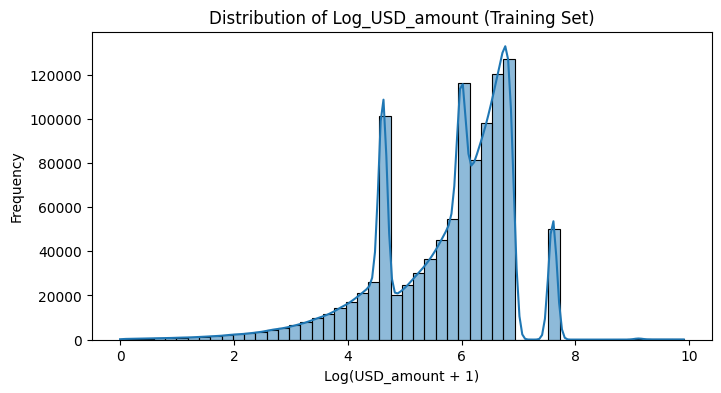

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply log1p transformation to USD_amount to handle right-skewness
for dataset in [X_train, X_val, X_test]:
    dataset['Log_USD_amount'] = np.log1p(dataset['USD_amount'])

# Drop the original USD_amount column
for dataset in [X_train, X_val, X_test]:
    dataset.drop(columns=['USD_amount'], inplace=True)

print("Applied log transformation to USD_amount.")

# Plot the new distribution for the training set
plt.figure(figsize=(8, 4))
sns.histplot(X_train['Log_USD_amount'], bins=50, kde=True)
plt.title('Distribution of Log_USD_amount (Training Set)')
plt.xlabel('Log(USD_amount + 1)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Initialize the scaler
# RobustScaler is less prone to being skewed by outliers than StandardScaler
scaler = RobustScaler()

# Define the numerical columns to scale
num_cols = ['Log_USD_amount']

# Fit on the training data and transform train, val, and test
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Scaled numerical features using RobustScaler.")
display(X_train.head())

Scaled numerical features using RobustScaler.


,Hour_of_Day,Is_New_Beneficiary,Is_New_Sector,Is_Round_Amount,Same_Country,Sender_ID_Missing,Bene_ID_Missing,Transaction_Type_DEPOSIT-CASH,Transaction_Type_DEPOSIT-CHECK,Transaction_Type_EXCHANGE,Transaction_Type_MAKE-PAYMENT,Transaction_Type_MOVE-FUNDS,Transaction_Type_PAY-CHECK,Transaction_Type_QUICK-PAYMENT,Transaction_Type_WITHDRAWAL,Sender_Continent_Africa,Sender_Continent_Antarctica,Sender_Continent_Asia,Sender_Continent_Europe,Sender_Continent_Missing,Sender_Continent_North America,Sender_Continent_Oceania,Sender_Continent_South America,Sender_Continent_Unknown,Bene_Continent_Africa,Bene_Continent_Antarctica,Bene_Continent_Asia,Bene_Continent_Europe,Bene_Continent_Missing,Bene_Continent_North America,Bene_Continent_Oceania,Bene_Continent_South America,Bene_Continent_Unknown,Day_of_Week_Friday,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Log_USD_amount
511707,6,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,-1.526427
1049769,23,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0.225211
1494953,10,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0.317630
215886,22,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,-0.902030
743597,11,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,-0.795432


In [ ]:
import pandas as pd

# Define bins and labels for hour of day
bins = [0, 6, 12, 18, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

for dataset in [X_train, X_val, X_test]:
    # Create binned categorical variable, right=False means intervals are [a, b)
    dataset['Time_of_Day'] = pd.cut(dataset['Hour_of_Day'], bins=bins, labels=labels, right=False)

    # Drop the original Hour_of_Day column
    dataset.drop(columns=['Hour_of_Day'], inplace=True)

# Convert the new categorical variable into dummy variables
X_train = pd.get_dummies(X_train, columns=['Time_of_Day'])
X_val = pd.get_dummies(X_val, columns=['Time_of_Day'])
X_test = pd.get_dummies(X_test, columns=['Time_of_Day'])

# Align columns to ensure consistency across splits
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Convert boolean columns to integer if get_dummies returned booleans (Pandas 2.0+ behavior)
for col in X_train.columns:
    if X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
        X_val[col] = X_val[col].astype(int)
        X_test[col] = X_test[col].astype(int)

print("Binned Hour_of_Day into Time_of_Day categories and created dummy variables.")
display(X_train.head())

Binned Hour_of_Day into Time_of_Day categories and created dummy variables.


,Is_New_Beneficiary,Is_New_Sector,Is_Round_Amount,Same_Country,Sender_ID_Missing,Bene_ID_Missing,Transaction_Type_DEPOSIT-CASH,Transaction_Type_DEPOSIT-CHECK,Transaction_Type_EXCHANGE,Transaction_Type_MAKE-PAYMENT,Transaction_Type_MOVE-FUNDS,Transaction_Type_PAY-CHECK,Transaction_Type_QUICK-PAYMENT,Transaction_Type_WITHDRAWAL,Sender_Continent_Africa,Sender_Continent_Antarctica,Sender_Continent_Asia,Sender_Continent_Europe,Sender_Continent_Missing,Sender_Continent_North America,Sender_Continent_Oceania,Sender_Continent_South America,Sender_Continent_Unknown,Bene_Continent_Africa,Bene_Continent_Antarctica,Bene_Continent_Asia,Bene_Continent_Europe,Bene_Continent_Missing,Bene_Continent_North America,Bene_Continent_Oceania,Bene_Continent_South America,Bene_Continent_Unknown,Day_of_Week_Friday,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Log_USD_amount,Time_of_Day_Night,Time_of_Day_Morning,Time_of_Day_Afternoon,Time_of_Day_Evening
511707,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,-1.526427,0,1,0,0
1049769,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0.225211,0,0,0,1
1494953,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0.317630,0,1,0,0
215886,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,-0.902030,0,0,0,1
743597,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,-0.795432,0,1,0,0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Initialize the Logistic Regression model
# Using class_weight='balanced' to handle the highly imbalanced fraud dataset
# 'saga' solver is fast for large datasets and supports both l1 and l2 penalties
log_reg = LogisticRegression(class_weight='balanced', solver='saga', max_iter=1000, random_state=42)

# Define the parameter grid to test
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2']
}

# Set up GridSearchCV
# cv=3 for 3-fold cross-validation to save time, scoring on ROC AUC
grid_search = GridSearchCV(log_reg, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=2)

print("Starting Grid Search. This might take a few minutes on ~1 million rows...")
grid_search.fit(X_train, y_train)

print("\nGrid Search Complete!")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation ROC AUC:", grid_search.best_score_)

# Evaluate the best model on the validation set
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

print("\n--- Validation Set Performance ---")
print("Classification Report:")
print(classification_report(y_val, y_val_pred))

auc_score = roc_auc_score(y_val, y_val_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

Starting Grid Search. This might take a few minutes on ~1 million rows...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Grid Search Complete!
Best Parameters: {'C': 0.01, 'penalty': 'l2'}
Best Cross-Validation ROC AUC: 0.6130946344680804

--- Validation Set Performance ---
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.54      0.70    220104
           1       0.03      0.63      0.05      4623

    accuracy                           0.54    224727
   macro avg       0.51      0.58      0.37    224727
weighted avg       0.97      0.54      0.68    224727

ROC AUC Score: 0.6070


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


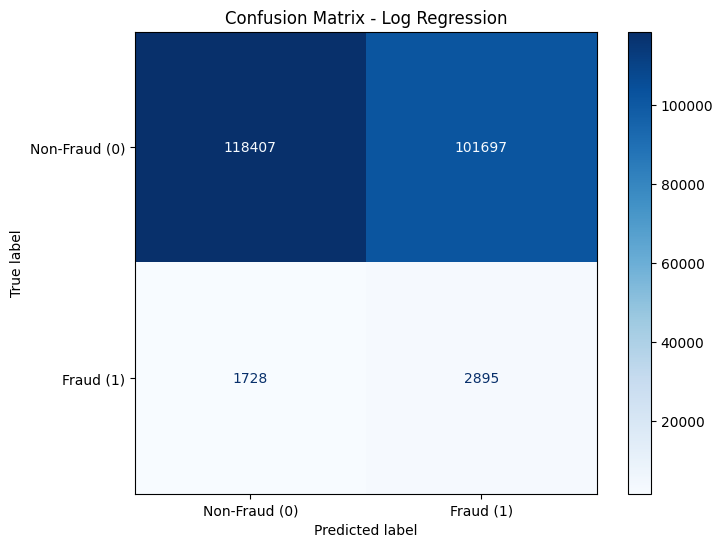

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud (0)', 'Fraud (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix - Log Regression')
plt.grid(False) # Turn off grid for cleaner matrix view
plt.show()

In [ ]:
#Install package to optomize XGBoost

!pip install scikit-optimize

In [ ]:
!pip install -q xgboost

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from xgboost import XGBClassifier
import time


# Calculate the ratio of negative to positive cases for scale_pos_weight
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_pos_weight = neg_class_count / pos_class_count
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

params = {
    'n_estimators':Integer(50, 1000),
    'max_depth':Integer(1, 50),
    'learning_rate':Real(.001, .7),
    'gamma':Real(.0001, 10),
    'reg_lambda':Real(.0001, 10),
    'reg_alpha':Real(.0001, 10)
    # 'scale_pos_weight' is removed from here as it's a fixed value
}

#create abyes search with average_precision scoring for imbalanced data
bayes_cv = BayesSearchCV(
    XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight), # Pass scale_pos_weight directly here
    params,
    cv=10,
    n_iter=20,
    n_jobs=-1,
    scoring='roc_auc_ovr_weighted',
    random_state=42
)

bayes_cv.fit(X_train, y_train)


#best params
print(bayes_cv.best_params_)

#best score
print(bayes_cv.best_score_)


Calculated scale_pos_weight: 47.61
OrderedDict({'gamma': 7.992745396416778, 'learning_rate': 0.7, 'max_depth': 3, 'n_estimators': 696, 'reg_alpha': 0.0001, 'reg_lambda': 10.0})
0.693453311264961


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model = bayes_cv.best_estimator_
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1] # Get probabilities for the positive class

print(f'Accuracy: {accuracy_score(y_val, y_pred)}')
print(f'Precision: {precision_score(y_val, y_pred)}')
print(f'Recall: {recall_score(y_val, y_pred)}')
print(f'F1 Score: {f1_score(y_val, y_pred)}')
print(f'ROC AUC Score: {roc_auc_score(y_val, y_pred_proba)}') # Calculate and print ROC AUC

Accuracy: 0.384421987567137
Precision: 0.029268876559551637
Recall: 0.899199653904391
F1 Score: 0.05669241941752869
ROC AUC Score: 0.6988609401125611


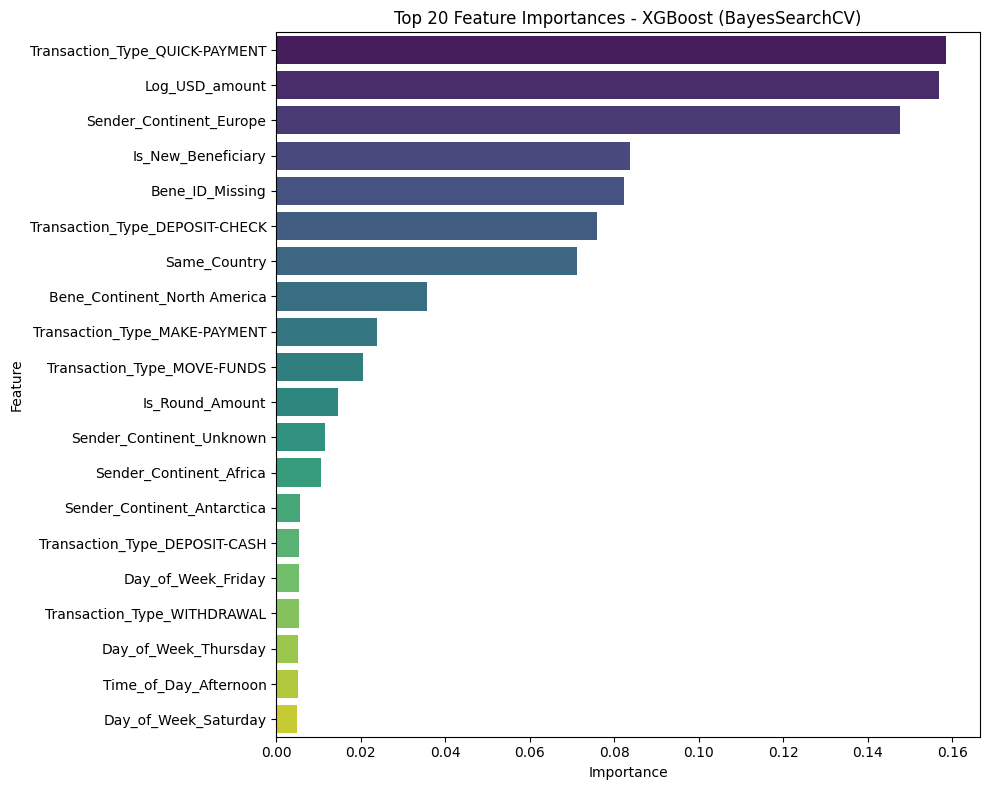

,Feature,Importance
12,Transaction_Type_QUICK-PAYMENT,0.158606
39,Log_USD_amount,0.156807
17,Sender_Continent_Europe,0.147702
0,Is_New_Beneficiary,0.083825
5,Bene_ID_Missing,0.082329
7,Transaction_Type_DEPOSIT-CHECK,0.075840
3,Same_Country,0.071146
28,Bene_Continent_North America,0.035737
9,Transaction_Type_MAKE-PAYMENT,0.023799
10,Transaction_Type_MOVE-FUNDS,0.020502


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the tuned model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(20), palette='viridis', legend=False)
plt.title('Top 20 Feature Importances - XGBoost (BayesSearchCV)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Display the top 10 features in a table format
display(feature_importance_df.head(10))

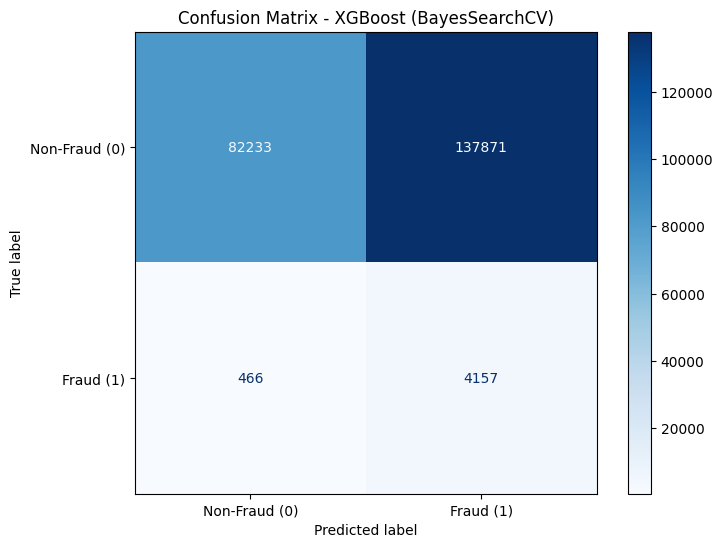

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud (0)', 'Fraud (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix - XGBoost (BayesSearchCV)')
plt.grid(False) # Turn off grid for cleaner matrix view
plt.show()